# 🔄 Matrices as Linear Maps — How a 2×2 Matrix Warps the Plane

**Linear Algebra and Analytic Geometry** · TSIW, ESMAD — Polytechnic of Porto
Lesson notebook **02 of 08** · Library: [`linalg_utils`](../packages/python/src/linalg_utils)

> **Assignment alignment** — supports assignments **A1** (matrix construction and
> classification) and **A2** (matrix operations).

---

A matrix is usually introduced as a grid of numbers. The far more useful mental model is:

> **A matrix is a function.** $A$ eats a vector $\mathbf{x}$ and returns a new vector
> $A\mathbf{x}$ — and it does so *linearly*: grids stay grids, the origin stays put,
> parallel lines stay parallel.

In this notebook we make that function visible: we track what $A$ does to single vectors, to
the basis, to the unit square and circle, and we meet the four classic transforms —
rotation, scaling, shear, reflection — plus what happens when you compose them.

## Table of contents

1. [Setup](#setup)
2. [Building blocks: the matrices of assignment A1](#building)
3. [A matrix is a function](#function)
4. [The two columns tell you everything](#columns)
5. [Unit square → parallelogram (and the determinant)](#square)
6. [Unit circle → ellipse](#circle)
7. [A zoo of transforms](#zoo)
8. [Composition: matrix product = "do one, then the other"](#composition)
9. [Key takeaways](#takeaways)

<a id="setup"></a>
## 1 · Setup

In [1]:
# ── Setup: imports, course library, and a consistent figure style ──────────
import sys
from pathlib import Path

# Make the course library importable straight from a repo clone
# (equivalent to `poetry install` inside packages/python).
_SRC = (Path.cwd().parent / "packages" / "python" / "src").resolve()
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette, used in fixed order across the series.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor":   BASE,
    "axes.labelcolor":  INK,
    "axes.titlecolor":  INK,
    "axes.titleweight": "bold",
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.prop_cycle":  plt.cycler(color=PALETTE),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "figure.dpi":       110,
})
np.set_printoptions(precision=4, suppress=True)

import linalg_utils
print("NumPy", np.__version__, "| linalg_utils loaded from", Path(linalg_utils.__file__).parent)

NumPy 2.3.5 | linalg_utils loaded from C:\Users\diogo\work_code\linear-algebra-with-python\packages\python\src\linalg_utils


<a id="building"></a>
## 2 · Building blocks: the matrices of assignment A1

Before matrices *move* things, assignment A1 asks you to *build and classify* them. The
course library ships constructors (Portuguese names, matching the assignment statements) for
the standard special matrices — null, identity, diagonal, triangular, symmetric — and a
classifier that reports every property a matrix satisfies.

In [2]:
from linalg_utils.matrices import (
    criar_identidade, criar_diagonal, criar_triangular_superior,
    criar_simetrica, classificar_matriz, dimensao,
)

I3 = criar_identidade(3)
D = criar_diagonal([2.0, -1.0, 3.0])
U = criar_triangular_superior([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
S = criar_simetrica(3, seed=42)

for name, M in [("identity I₃", I3), ("diagonal D", D),
                ("upper-triangular U", U), ("random symmetric S", S)]:
    print(f"{name}  {dimensao(M)} → {classificar_matriz(M)}")
    print(M, end="\n\n")

identity I₃  (3, 3) → ['square', 'identity', 'diagonal', 'symmetric', 'upper_triangular', 'lower_triangular']
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

diagonal D  (3, 3) → ['square', 'diagonal', 'symmetric', 'upper_triangular', 'lower_triangular']
[[ 2.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  3.]]

upper-triangular U  (3, 3) → ['square', 'upper_triangular']
[[1. 2. 3.]
 [0. 5. 6.]
 [0. 0. 9.]]

random symmetric S  (3, 3) → ['square', 'symmetric']
[[ 0.3047 -0.0497  0.4391]
 [-0.0497 -1.951  -0.8092]
 [ 0.4391 -0.8092 -0.0168]]



<a id="function"></a>
## 3 · A matrix is a function

Our running example for the rest of the notebook:

$$A = \begin{pmatrix} 1.5 & 0.5 \\ -0.5 & 1.2 \end{pmatrix},
\qquad A\mathbf{x} \text{ is computed as } A \texttt{ @ } \mathbf{x}.$$

Below, one input vector and its image. Notice the map both *rotates* and *stretches* — a
general matrix mixes behaviors.

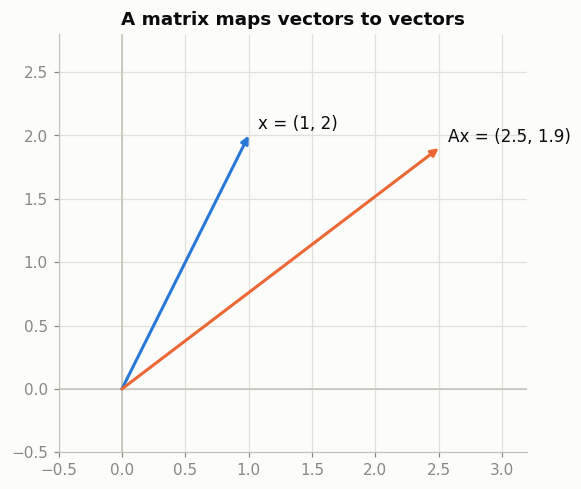

x  = [1. 2.]
Ax = [2.5 1.9]


In [3]:
A = np.array([[1.5, 0.5], [-0.5, 1.2]])
x = np.array([1.0, 2.0])
Ax = A @ x


def draw_vector(ax, vec, *, color, label, ls="-"):
    ax.annotate("", xy=tuple(vec), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                linestyle=ls, shrinkA=0, shrinkB=0))
    ax.annotate(label, xy=tuple(vec), xytext=(6, 4),
                textcoords="offset points", color=INK, fontsize=11)


fig, ax = plt.subplots(figsize=(5.5, 5))
draw_vector(ax, x, color=PALETTE[0], label="x = (1, 2)")
draw_vector(ax, Ax, color=PALETTE[1], label=f"Ax = ({Ax[0]:.1f}, {Ax[1]:.1f})")
ax.set_xlim(-0.5, 3.2)
ax.set_ylim(-0.5, 2.8)
ax.set_aspect("equal")
ax.axhline(0, color=BASE, lw=1)
ax.axvline(0, color=BASE, lw=1)
ax.set_title("A matrix maps vectors to vectors")
plt.show()

print("x  =", x)
print("Ax =", Ax)

<a id="columns"></a>
## 4 · The two columns tell you everything

Feed the standard basis through $A$ and something remarkable falls out:

$$A\mathbf{e}_1 = \begin{pmatrix} 1.5 \\ -0.5 \end{pmatrix} = \text{column 1},
\qquad
A\mathbf{e}_2 = \begin{pmatrix} 0.5 \\ 1.2 \end{pmatrix} = \text{column 2}.$$

**The columns of $A$ are the images of the basis vectors.** Since every
$\mathbf{x} = x_1\mathbf{e}_1 + x_2\mathbf{e}_2$ and the map is linear,

$$A\mathbf{x} = x_1(A\mathbf{e}_1) + x_2(A\mathbf{e}_2),$$

knowing where $\mathbf{e}_1, \mathbf{e}_2$ land determines where *everything* lands.

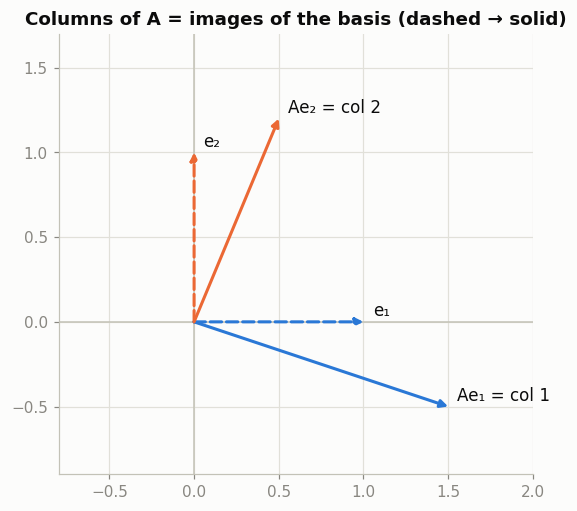

A(2e₁+3e₂) = [4.5 2.6]  = 2·col₁ + 3·col₂ = [4.5 2.6]


In [4]:
e1, e2 = np.eye(2)

fig, ax = plt.subplots(figsize=(5.8, 5.2))
draw_vector(ax, e1, color=PALETTE[0], label="e₁", ls="--")
draw_vector(ax, e2, color=PALETTE[1], label="e₂", ls="--")
draw_vector(ax, A @ e1, color=PALETTE[0], label="Ae₁ = col 1")
draw_vector(ax, A @ e2, color=PALETTE[1], label="Ae₂ = col 2")
ax.set_xlim(-0.8, 2.0)
ax.set_ylim(-0.9, 1.7)
ax.set_aspect("equal")
ax.axhline(0, color=BASE, lw=1)
ax.axvline(0, color=BASE, lw=1)
ax.set_title("Columns of A = images of the basis (dashed → solid)")
plt.show()

# Linearity in action: A(2e₁ + 3e₂) must equal 2·col1 + 3·col2.
lhs = A @ (2 * e1 + 3 * e2)
rhs = 2 * A[:, 0] + 3 * A[:, 1]
print("A(2e₁+3e₂) =", lhs, " = 2·col₁ + 3·col₂ =", rhs)

<a id="square"></a>
## 5 · Unit square → parallelogram (and the determinant)

Linearity means the whole unit square is carried to the **parallelogram** spanned by the two
columns. The *area* of that parallelogram is $|\det A|$ — the determinant is the map's
**area scaling factor** (a preview of notebook 03's sibling topic and assignment A3).

The library's `geometry2d` module provides the sampled shapes and the mapping helper.

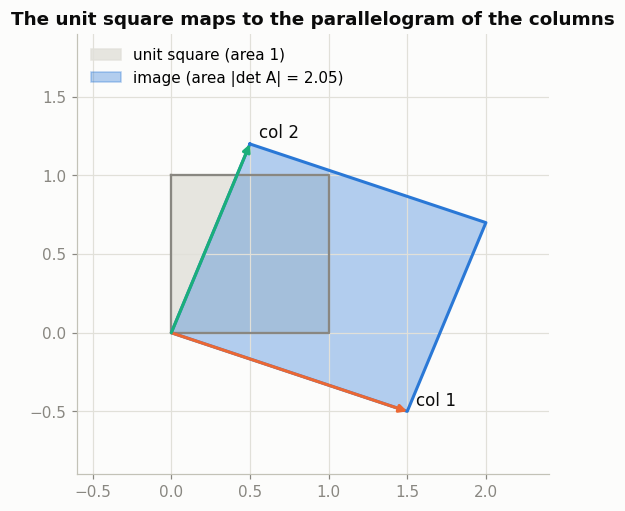

det A = 2.0500 → the map scales every area by 2.0500


In [5]:
from linalg_utils.geometry2d import unit_square, apply_linear_map

square = unit_square()
mapped_square = apply_linear_map(A, square)
detA = np.linalg.det(A)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.fill(square[:, 0], square[:, 1], color=GRID, alpha=0.8, label="unit square (area 1)")
ax.plot(square[:, 0], square[:, 1], color=MUTED, lw=1.5)
ax.fill(mapped_square[:, 0], mapped_square[:, 1], color=PALETTE[0], alpha=0.35,
        label=f"image (area |det A| = {abs(detA):.2f})")
ax.plot(mapped_square[:, 0], mapped_square[:, 1], color=PALETTE[0], lw=2)
draw_vector(ax, A[:, 0], color=PALETTE[1], label="col 1")
draw_vector(ax, A[:, 1], color=PALETTE[2], label="col 2")
ax.set_xlim(-0.6, 2.4)
ax.set_ylim(-0.9, 1.9)
ax.set_aspect("equal")
ax.set_title("The unit square maps to the parallelogram of the columns")
ax.legend(loc="upper left")
plt.show()

print(f"det A = {detA:.4f} → the map scales every area by {abs(detA):.4f}")

<a id="circle"></a>
## 6 · Unit circle → ellipse

Squares show corners; circles show **directions**. A linear map sends the unit circle to an
ellipse, and the ellipse reveals which directions get stretched most and least — an idea that
returns with singular values (notebook 05) and eigenvectors (notebook 06).

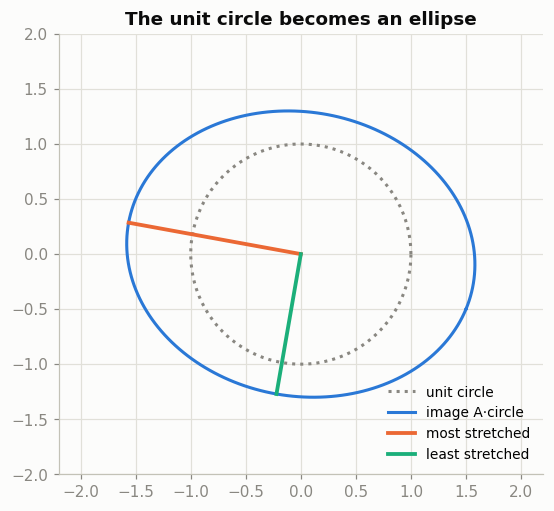

max stretch ≈ 1.590, min stretch ≈ 1.290 (the singular values of A: [1.5896 1.2896])


In [6]:
from linalg_utils.geometry2d import unit_circle

circle = unit_circle()
mapped_circle = apply_linear_map(A, circle)

fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.plot(circle[:, 0], circle[:, 1], color=MUTED, ls=":", lw=2, label="unit circle")
ax.plot(mapped_circle[:, 0], mapped_circle[:, 1], color=PALETTE[0], lw=2,
        label="image A·circle")
# annotate the longest and shortest radii of the image (singular directions)
radii = np.linalg.norm(mapped_circle, axis=1)
for idx, lab, colr in [(np.argmax(radii), "most stretched", PALETTE[1]),
                       (np.argmin(radii), "least stretched", PALETTE[2])]:
    pt = mapped_circle[idx]
    ax.plot([0, pt[0]], [0, pt[1]], color=colr, lw=2.5, label=lab)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal")
ax.set_title("The unit circle becomes an ellipse")
ax.legend(loc="lower right", fontsize=9)
plt.show()

print(f"max stretch ≈ {radii.max():.3f}, min stretch ≈ {radii.min():.3f} "
      f"(the singular values of A: {np.linalg.svd(A, compute_uv=False)})")

<a id="zoo"></a>
## 7 · A zoo of transforms

Four families of 2×2 matrices cover most geometric behavior. Each panel below shows the unit
circle + square and their images, with the matrix and its determinant in the title:

| transform | matrix | determinant |
|---|---|---|
| rotation by $\theta$ | $\begin{pmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{pmatrix}$ | $+1$ (rigid) |
| scaling | $\begin{pmatrix}s_x & 0\\ 0 & s_y\end{pmatrix}$ | $s_x s_y$ |
| shear | $\begin{pmatrix}1 & k\\ 0 & 1\end{pmatrix}$ | $+1$ (area-preserving!) |
| reflection | flips across a line | $-1$ (orientation reverses) |

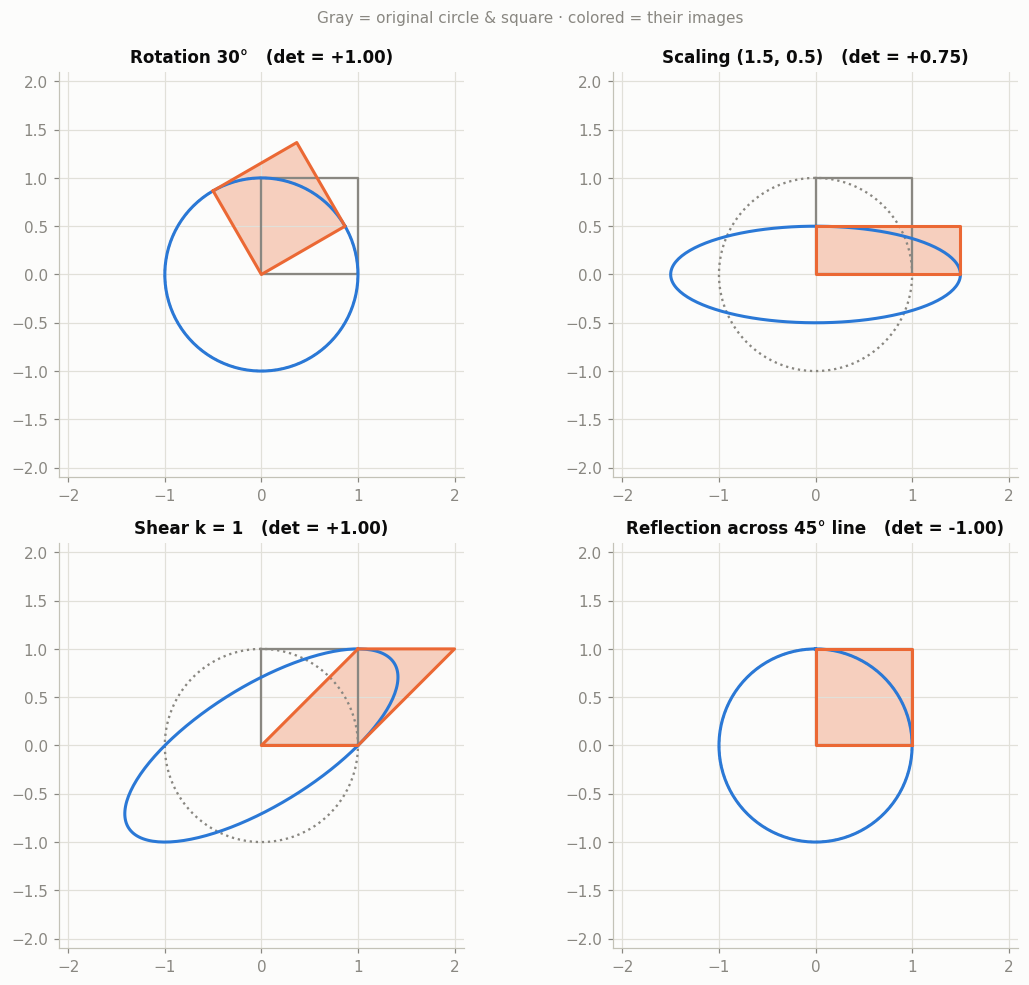

In [7]:
def rotation(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

def scaling(sx, sy):
    return np.diag([float(sx), float(sy)])

def shear(k):
    return np.array([[1.0, float(k)], [0.0, 1.0]])

def reflection(theta):
    """Reflection across the line at angle `theta` through the origin."""
    R = rotation(theta)
    return R @ np.diag([1.0, -1.0]) @ R.T

examples = [
    ("Rotation 30°", rotation(np.pi / 6)),
    ("Scaling (1.5, 0.5)", scaling(1.5, 0.5)),
    ("Shear k = 1", shear(1.0)),
    ("Reflection across 45° line", reflection(np.pi / 4)),
]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 9))
for ax, (title, M) in zip(axes.ravel(), examples):
    ax.plot(circle[:, 0], circle[:, 1], color=MUTED, ls=":", lw=1.5)
    ax.plot(square[:, 0], square[:, 1], color=MUTED, lw=1.5)
    mc = apply_linear_map(M, circle)
    ms = apply_linear_map(M, square)
    ax.plot(mc[:, 0], mc[:, 1], color=PALETTE[0], lw=2)
    ax.fill(ms[:, 0], ms[:, 1], color=PALETTE[1], alpha=0.30)
    ax.plot(ms[:, 0], ms[:, 1], color=PALETTE[1], lw=2)
    ax.set_xlim(-2.1, 2.1)
    ax.set_ylim(-2.1, 2.1)
    ax.set_aspect("equal")
    ax.set_title(f"{title}   (det = {np.linalg.det(M):+.2f})", fontsize=11)
fig.suptitle("Gray = original circle & square · colored = their images", y=0.99,
             fontsize=10, color=MUTED)
plt.tight_layout()
plt.show()

<a id="composition"></a>
## 8 · Composition: matrix product = "do one, then the other"

Applying $B$ then $A$ is a single linear map with matrix $AB$ — **matrix multiplication is
function composition**. Composition explains why the product is generally *not*
commutative: shearing a rotated square is not the same as rotating a sheared square.

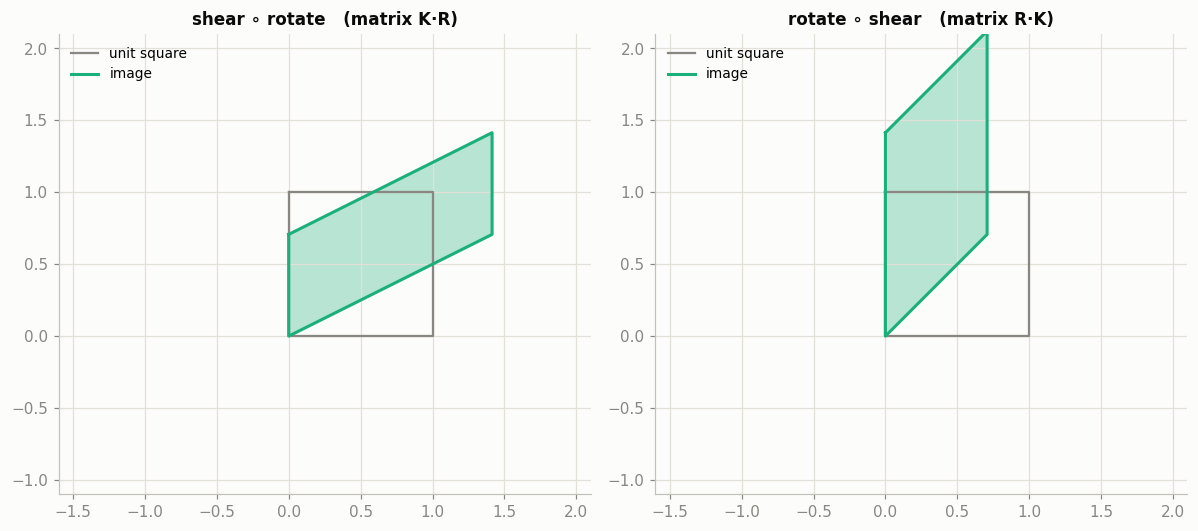

K@R =
 [[1.4142 0.    ]
 [0.7071 0.7071]]
R@K =
 [[0.7071 0.    ]
 [0.7071 1.4142]]
Commutative? False


In [8]:
R = rotation(np.pi / 4)   # rotate 45°
K = shear(1.0)            # then shear

first_rotate = apply_linear_map(K @ R, square)   # rotate, THEN shear  → matrix K·R
first_shear  = apply_linear_map(R @ K, square)   # shear, THEN rotate  → matrix R·K

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, ms, title in [
    (axes[0], first_rotate, "shear ∘ rotate   (matrix K·R)"),
    (axes[1], first_shear,  "rotate ∘ shear   (matrix R·K)"),
]:
    ax.plot(square[:, 0], square[:, 1], color=MUTED, lw=1.5, label="unit square")
    ax.fill(ms[:, 0], ms[:, 1], color=PALETTE[2], alpha=0.30)
    ax.plot(ms[:, 0], ms[:, 1], color=PALETTE[2], lw=2, label="image")
    ax.set_xlim(-1.6, 2.1)
    ax.set_ylim(-1.1, 2.1)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11)
    ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print("K@R =\n", K @ R)
print("R@K =\n", R @ K)
print("Commutative?", bool(np.allclose(K @ R, R @ K)))

<a id="takeaways"></a>
## 9 · Key takeaways

- A matrix **is a linear function**; its columns are the images of the basis vectors — read
  the columns and you can *see* the map before computing anything.
- The unit square goes to the **parallelogram of the columns**; its area is $|\det A|$,
  making the determinant a geometric quantity, not just a formula.
- The unit circle goes to an **ellipse** whose axes preview singular values (notebook 05)
  and eigen-directions (notebook 06).
- Rotations and shears preserve area ($\det = 1$); reflections flip orientation
  ($\det = -1$); scalings multiply area by $s_x s_y$.
- **Matrix product = composition of maps**, which is why $AB \ne BA$ in general.

**Next:** [03 — Solving linear systems](03_solving_linear_systems.ipynb): running the map
backwards, i.e. finding $\mathbf{x}$ given $A\mathbf{x} = \mathbf{b}$.